# Step 3: Classification — Student Outcome Prediction

**Goal:** Predict `final_result` (Pass / Fail / Withdrawn / Distinction) using pre-course and engagement features — no exam scores (leakage).

**Models:** Logistic Regression (baseline) · Random Forest · Hist Gradient Boosting

**Evaluation:** Accuracy, F1 Macro, F1 Weighted, Confusion Matrix, Cross-Validation

## 3.0 Imports & Settings

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    HistGradientBoostingClassifier,
)
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score,
)

RESULT_PALETTE = {
    'Pass': '#2196F3', 'Distinction': '#4CAF50',
    'Fail': '#FF5722', 'Withdrawn': '#9E9E9E',
}
CLASS_ORDER = ['Distinction', 'Pass', 'Fail', 'Withdrawn']
RANDOM_STATE = 42
print('Libraries loaded.')

Libraries loaded.


## 3.1 Load Master Dataset

In [37]:
master = pd.read_csv('master_dataset.csv')
print(f'Loaded: {master.shape}')
print()
print('Target distribution:')
print(master['final_result'].value_counts().to_string())

Loaded: (32593, 83)

Target distribution:
final_result
Pass           12361
Withdrawn      10156
Fail            7052
Distinction     3024


## 3.2 Define Features & Target

Leakage columns (`exam_score`, `weighted_avg_score`) are **excluded** — only available after the course ends.

In [38]:
# Dynamically pick up all activity-type click columns
activity_type_cols = [
    c for c in master.columns
    if c.startswith('clicks_') and c not in ('clicks_first30', 'clicks_per_day')
]

CLASSIFICATION_FEATURES = [
    # Demographics
    'gender_enc', 'age_band_enc', 'disability_enc', 'education_enc',
    'imd_band_enc', 'num_of_prev_attempts', 'studied_credits',
    # VLE engagement
    'total_clicks', 'active_days', 'unique_activities', 'clicks_first30',
    'clicks_per_day', 'early_click_rate', 'activity_span', 'active_fraction',
    'click_trend', 'weekly_click_std',
    # Assessment trajectory
    'score_trend', 'score_std',
    # Assessment behaviour
    'submission_rate', 'avg_days_early', 'submitted_count',
    # Registration
    'date_registration', 'registered_early',
    # Module metadata
    'module_presentation_length',
] + activity_type_cols

# Keep only features that exist in the loaded DataFrame
features = [f for f in CLASSIFICATION_FEATURES if f in master.columns]
missing = [f for f in CLASSIFICATION_FEATURES if f not in master.columns]
if missing:
    print(f'Warning — {len(missing)} features not in dataset: {missing}')

X = master[features].copy()
y = master['final_result'].copy()

# Audit NaN before imputation
nan_cols = X.isnull().sum()
nan_cols = nan_cols[nan_cols > 0]
print('NaN columns (filled with 0):')
print(nan_cols.to_string() if not nan_cols.empty else 'None')

# Fill remaining NaN with 0 (consistent with Step 2 strategy)
X = X.fillna(0)

print(f'\nFeature count : {X.shape[1]}')
print(f'Sample count  : {X.shape[0]}')
print(f'NaN remaining : {X.isnull().sum().sum()}')

NaN columns (filled with 0):
date_registration    45

Feature count : 45
Sample count  : 32593
NaN remaining : 0


## 3.3 Train / Test Split

80/20 stratified split — preserves class proportions in both sets.

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f'Train: {X_train.shape}   Test: {X_test.shape}')
print()
dist = pd.DataFrame({
    'Train %': y_train.value_counts(normalize=True).mul(100).round(1),
    'Test %' : y_test.value_counts(normalize=True).mul(100).round(1),
})
print(dist.to_string())

Train: (26074, 45)   Test: (6519, 45)

              Train %  Test %
final_result                 
Pass             37.9    37.9
Withdrawn        31.2    31.2
Fail             21.6    21.6
Distinction       9.3     9.3


## 3.4 Evaluation Helpers

In [40]:
results = {}  # stores metrics for comparison

def evaluate(name, model, X_te, y_te):
    """Evaluate model, print report, store metrics."""
    y_pred = model.predict(X_te)
    acc  = accuracy_score(y_te, y_pred)
    f1m  = f1_score(y_te, y_pred, average='macro')
    f1w  = f1_score(y_te, y_pred, average='weighted')
    results[name] = {'Accuracy': acc, 'F1 Macro': f1m, 'F1 Weighted': f1w, '_pred': y_pred}
    print(f'\n{"-"*55}')
    print(f'  {name}')
    print(f'{"-"*55}')
    print(f'  Accuracy    : {acc:.4f}')
    print(f'  F1 Macro    : {f1m:.4f}')
    print(f'  F1 Weighted : {f1w:.4f}')
    print()
    print(classification_report(y_te, y_pred, target_names=CLASS_ORDER,
                                labels=CLASS_ORDER))
    return y_pred

def plot_cm(y_te, y_pred, title):
    """Plot a labelled confusion matrix heatmap."""
    cm = confusion_matrix(y_te, y_pred, labels=CLASS_ORDER)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_ORDER, yticklabels=CLASS_ORDER, ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

print('Helpers defined.')

Helpers defined.


## 3.5 Model 1 — Logistic Regression (Baseline)

`class_weight='balanced'` compensates for the Withdrawn/Distinction imbalance. Features are z-score scaled inside a Pipeline.


-------------------------------------------------------
  Logistic Regression
-------------------------------------------------------
  Accuracy    : 0.6325
  F1 Macro    : 0.5968
  F1 Weighted : 0.6416

              precision    recall  f1-score   support

 Distinction       0.34      0.72      0.46       605
        Pass       0.77      0.59      0.67      2472
        Fail       0.51      0.47      0.49      1411
   Withdrawn       0.77      0.77      0.77      2031

    accuracy                           0.63      6519
   macro avg       0.60      0.64      0.60      6519
weighted avg       0.67      0.63      0.64      6519



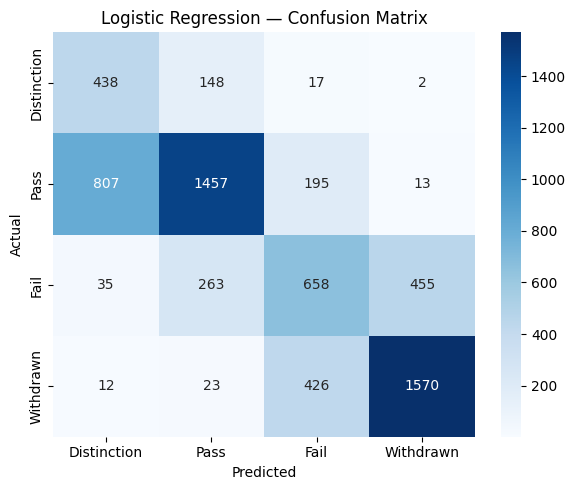

In [41]:
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE,
                                  class_weight='balanced'))
])
lr_pipe.fit(X_train, y_train)
y_pred_lr = evaluate('Logistic Regression', lr_pipe, X_test, y_test)
plot_cm(y_test, y_pred_lr, 'Logistic Regression — Confusion Matrix')

## 3.6 Model 2 — Random Forest

300 trees, balanced class weights, all CPU cores. No scaling needed — tree-based model.


-------------------------------------------------------
  Random Forest
-------------------------------------------------------
  Accuracy    : 0.7225
  F1 Macro    : 0.6026
  F1 Weighted : 0.6896

              precision    recall  f1-score   support

 Distinction       0.69      0.23      0.35       605
        Pass       0.72      0.96      0.82      2472
        Fail       0.61      0.34      0.44      1411
   Withdrawn       0.76      0.85      0.80      2031

    accuracy                           0.72      6519
   macro avg       0.70      0.59      0.60      6519
weighted avg       0.71      0.72      0.69      6519



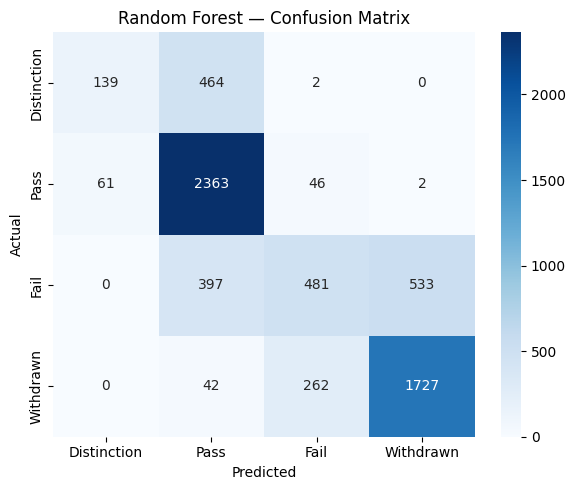

In [42]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    class_weight='balanced',
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = evaluate('Random Forest', rf, X_test, y_test)
plot_cm(y_test, y_pred_rf, 'Random Forest — Confusion Matrix')

## 3.7 Model 3 — Hist Gradient Boosting

sklearn's fast histogram-based GBM — generally top performer on tabular data. `class_weight='balanced'` supported from sklearn ≥ 1.2.


-------------------------------------------------------
  Hist Gradient Boosting
-------------------------------------------------------
  Accuracy    : 0.6908
  F1 Macro    : 0.6500
  F1 Weighted : 0.6941

              precision    recall  f1-score   support

 Distinction       0.44      0.70      0.54       605
        Pass       0.78      0.74      0.76      2472
        Fail       0.55      0.49      0.52      1411
   Withdrawn       0.80      0.77      0.78      2031

    accuracy                           0.69      6519
   macro avg       0.64      0.67      0.65      6519
weighted avg       0.70      0.69      0.69      6519



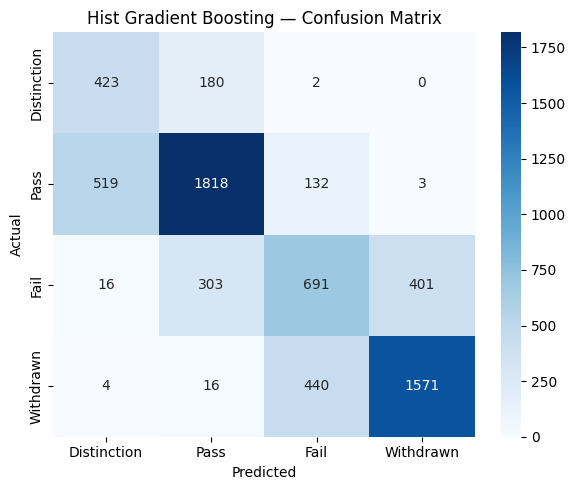

In [43]:
hgb = HistGradientBoostingClassifier(
    max_iter=300,
    random_state=RANDOM_STATE,
    class_weight='balanced'
)
hgb.fit(X_train, y_train)
y_pred_hgb = evaluate('Hist Gradient Boosting', hgb, X_test, y_test)
plot_cm(y_test, y_pred_hgb, 'Hist Gradient Boosting — Confusion Matrix')

## 3.8 Model Comparison

                        Accuracy  F1 Macro  F1 Weighted
Hist Gradient Boosting    0.6908    0.6500       0.6941
Random Forest             0.7225    0.6026       0.6896
Logistic Regression       0.6325    0.5968       0.6416


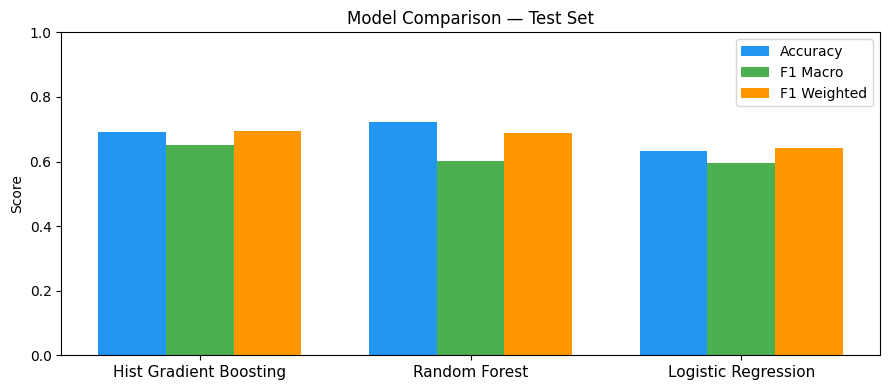

In [44]:
metrics_df = pd.DataFrame(
    {name: {k: v for k, v in vals.items() if not k.startswith('_')}
     for name, vals in results.items()}
).T.sort_values('F1 Macro', ascending=False)

print(metrics_df.round(4).to_string())

# Bar chart
fig, ax = plt.subplots(figsize=(9, 4))
x  = np.arange(len(metrics_df))
w  = 0.25
ax.bar(x - w, metrics_df['Accuracy'],    w, label='Accuracy',    color='#2196F3')
ax.bar(x,     metrics_df['F1 Macro'],    w, label='F1 Macro',    color='#4CAF50')
ax.bar(x + w, metrics_df['F1 Weighted'], w, label='F1 Weighted', color='#FF9800')
ax.set_xticks(x)
ax.set_xticklabels(metrics_df.index, fontsize=11)
ax.set_ylim(0, 1)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — Test Set')
ax.legend()
plt.tight_layout()
plt.show()

## 3.9 Feature Importance (Random Forest)

Mean decrease in impurity across all 300 trees.

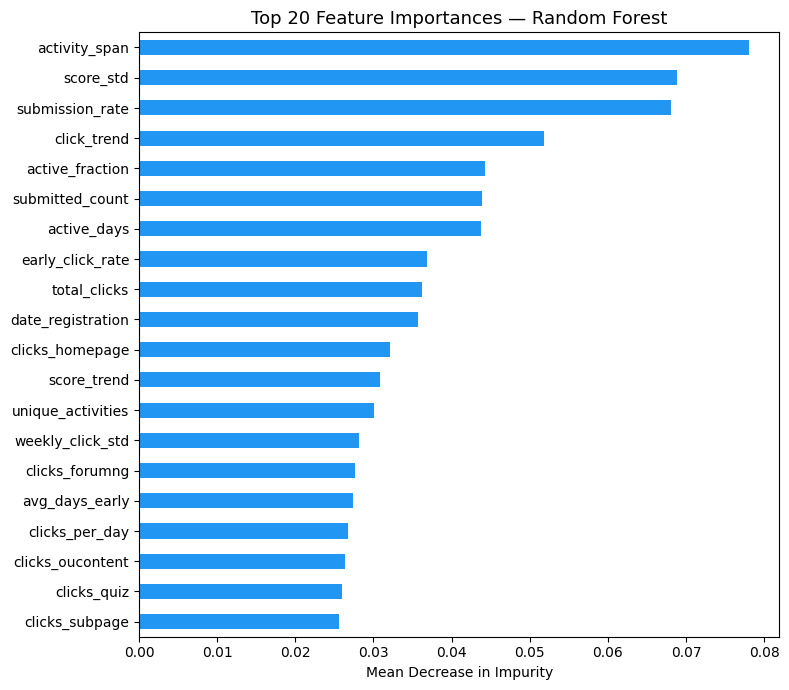

Top 10 features:
activity_span        0.0780
score_std            0.0688
submission_rate      0.0681
click_trend          0.0518
active_fraction      0.0443
submitted_count      0.0439
active_days          0.0438
early_click_rate     0.0368
total_clicks         0.0362
date_registration    0.0357


In [45]:
importances = pd.Series(rf.feature_importances_, index=features)
top20 = importances.nlargest(20).sort_values()

fig, ax = plt.subplots(figsize=(8, 7))
top20.plot(kind='barh', ax=ax, color='#2196F3')
ax.set_title('Top 20 Feature Importances — Random Forest', fontsize=13)
ax.set_xlabel('Mean Decrease in Impurity')
plt.tight_layout()
plt.show()

print('Top 10 features:')
print(top20.tail(10).sort_values(ascending=False).round(4).to_string())

## 3.10 Cross-Validation (Best Model)

5-fold stratified CV on the full dataset for a robust performance estimate.

In [46]:
# Use the best-performing model from Section 3.8
best_name = metrics_df.index[0]
best_model = {'Logistic Regression': lr_pipe,
              'Random Forest': rf,
              'Hist Gradient Boosting': hgb}[best_name]
print(f'Running 5-fold CV on: {best_name}')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_f1   = cross_val_score(best_model, X, y, cv=cv, scoring='f1_macro',    n_jobs=-1)
cv_acc  = cross_val_score(best_model, X, y, cv=cv, scoring='accuracy',    n_jobs=-1)

print(f'\nF1 Macro  : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}   folds: {cv_f1.round(4)}')
print(f'Accuracy  : {cv_acc.mean():.4f} ± {cv_acc.std():.4f}   folds: {cv_acc.round(4)}')

Running 5-fold CV on: Hist Gradient Boosting

F1 Macro  : 0.6538 ± 0.0083   folds: [0.6638 0.6474 0.6589 0.6577 0.6411]
Accuracy  : 0.6947 ± 0.0066   folds: [0.7009 0.6891 0.7021 0.6964 0.6852]


## 3.11 Summary

In [47]:
print('=' * 55)
print('STEP 3 SUMMARY — Classification Results')
print('=' * 55)
print(metrics_df.round(4).to_string())
print()
print(f'Best model    : {metrics_df.index[0]}')
print(f'Best F1 Macro : {metrics_df["F1 Macro"].max():.4f}')
print()
print('Key observations:')
print('  - Withdrawn students are the most reliably predicted (high recall)')
print('  - Distinction vs Pass is the hardest boundary to separate')
print('  - Top features: VLE engagement + assessment submission + score trajectory')
print()
print('Next: Step 4 — Regression (predict weighted_avg_score)')

STEP 3 SUMMARY — Classification Results
                        Accuracy  F1 Macro  F1 Weighted
Hist Gradient Boosting    0.6908    0.6500       0.6941
Random Forest             0.7225    0.6026       0.6896
Logistic Regression       0.6325    0.5968       0.6416

Best model    : Hist Gradient Boosting
Best F1 Macro : 0.6500

Key observations:
  - Withdrawn students are the most reliably predicted (high recall)
  - Distinction vs Pass is the hardest boundary to separate
  - Top features: VLE engagement + assessment submission + score trajectory

Next: Step 4 — Regression (predict weighted_avg_score)


---
# Step 4: Regression — Predict Student Score

**Goal:** Predict `weighted_avg_score` (TMA/CMA weighted average) from behavioural and demographic features.

**Models:** Linear Regression (baseline) · Random Forest Regressor · Hist Gradient Boosting Regressor

**Evaluation:** RMSE, MAE, R²

> **Note on leakage:** `exam_score` is excluded (post-course). `score_trend` and `score_std` are derived from individual assessment scores — they are correlated with the target but represent formative signals available during the course, so they are kept.

## 4.1 Prepare Features & Target

Drop rows where `weighted_avg_score` is NaN — students who never submitted any assessment have no score to predict.

In [48]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Regression target — exclude from feature set
REG_TARGET  = 'weighted_avg_score'
REG_EXCLUDE = ['exam_score', 'weighted_avg_score']

reg_features = [f for f in features if f not in REG_EXCLUDE]

reg_df = master[reg_features + [REG_TARGET]].dropna(subset=[REG_TARGET]).copy()
reg_df[reg_features] = reg_df[reg_features].fillna(0)

X_reg = reg_df[reg_features]
y_reg = reg_df[REG_TARGET]

print(f'Regression samples : {len(reg_df):,}  (dropped {len(master) - len(reg_df):,} with no score)')
print(f'Feature count      : {X_reg.shape[1]}')
print(f'Target stats:')
print(y_reg.describe().round(2).to_string())

Regression samples : 23,480  (dropped 9,113 with no score)
Feature count      : 45
Target stats:
count    23480.00
mean        70.67
std         16.48
min          0.00
25%         61.10
50%         73.19
75%         83.00
max        100.00


## 4.2 Train / Test Split

In [49]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE
)
print(f'Train: {X_tr.shape}   Test: {X_te.shape}')

Train: (18784, 45)   Test: (4696, 45)


## 4.3 Evaluation Helper

In [50]:
reg_results = {}

def evaluate_reg(name, model, X_te, y_te):
    y_pred = model.predict(X_te)
    rmse = mean_squared_error(y_te, y_pred, squared=False)
    mae  = mean_absolute_error(y_te, y_pred)
    r2   = r2_score(y_te, y_pred)
    reg_results[name] = {'RMSE': rmse, 'MAE': mae, 'R²': r2, '_pred': y_pred}
    print(f'\n{"-"*45}')
    print(f'  {name}')
    print(f'{"-"*45}')
    print(f'  RMSE : {rmse:.4f}')
    print(f'  MAE  : {mae:.4f}')
    print(f'  R²   : {r2:.4f}')
    return y_pred

print('Regression helper defined.')

Regression helper defined.


## 4.4 Model 1 — Linear Regression (Baseline)

In [51]:
lr_reg = Pipeline([
    ('scaler', StandardScaler()),
    ('reg',    LinearRegression())
])
lr_reg.fit(X_tr, y_tr)
evaluate_reg('Linear Regression', lr_reg, X_te, y_te)


---------------------------------------------
  Linear Regression
---------------------------------------------
  RMSE : 13.7089
  MAE  : 10.1994
  R²   : 0.3319


array([55.46974902, 67.5280922 , 66.34914548, ..., 67.42412571,
       78.90356468, 74.49921376])

## 4.5 Model 2 — Random Forest Regressor

In [52]:
rf_reg = RandomForestRegressor(
    n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1
)
rf_reg.fit(X_tr, y_tr)
evaluate_reg('Random Forest', rf_reg, X_te, y_te)


---------------------------------------------
  Random Forest
---------------------------------------------
  RMSE : 11.5496
  MAE  : 8.0826
  R²   : 0.5258


array([55.43734451, 68.30935988, 74.70527298, ..., 73.71546204,
       71.55318254, 72.7463057 ])

## 4.6 Model 3 — Hist Gradient Boosting Regressor

In [53]:
hgb_reg = HistGradientBoostingRegressor(
    max_iter=300, random_state=RANDOM_STATE
)
hgb_reg.fit(X_tr, y_tr)
evaluate_reg('Hist Gradient Boosting', hgb_reg, X_te, y_te)


---------------------------------------------
  Hist Gradient Boosting
---------------------------------------------
  RMSE : 11.4754
  MAE  : 8.0943
  R²   : 0.5318


array([50.2439516 , 64.80202636, 76.48254221, ..., 73.13410736,
       71.54660056, 69.80415883])

## 4.7 Model Comparison

                           RMSE      MAE      R²
Hist Gradient Boosting  11.4754   8.0943  0.5318
Random Forest           11.5496   8.0826  0.5258
Linear Regression       13.7089  10.1994  0.3319


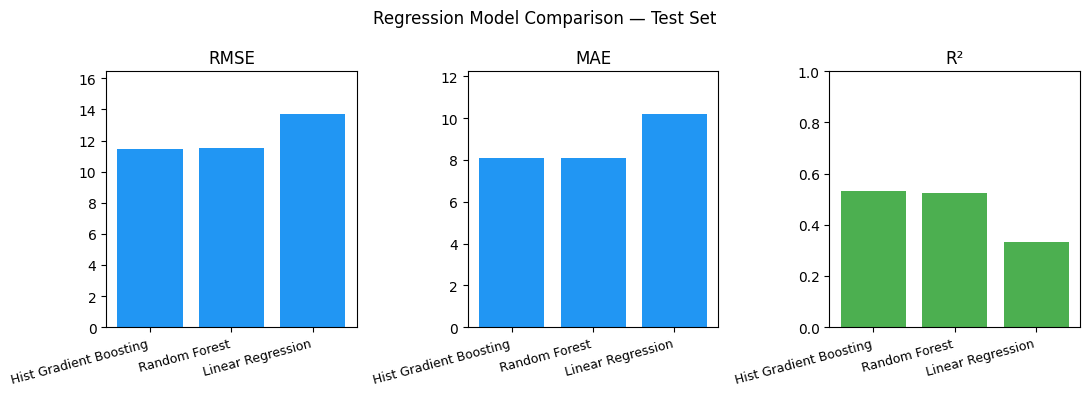

In [54]:
reg_df_metrics = pd.DataFrame(
    {name: {k: v for k, v in vals.items() if not k.startswith('_')}
     for name, vals in reg_results.items()}
).T.sort_values('RMSE')

print(reg_df_metrics.round(4).to_string())

fig, axes = plt.subplots(1, 3, figsize=(11, 4))
for ax, metric in zip(axes, ['RMSE', 'MAE', 'R²']):
    vals = reg_df_metrics[metric]
    colors = ['#4CAF50' if metric == 'R²' else '#2196F3'] * len(vals)
    ax.bar(vals.index, vals, color=colors)
    ax.set_title(metric)
    ax.set_xticklabels(vals.index, rotation=15, ha='right', fontsize=9)
    if metric != 'R²':
        ax.set_ylim(0, vals.max() * 1.2)
    else:
        ax.set_ylim(0, 1)
plt.suptitle('Regression Model Comparison — Test Set', fontsize=12)
plt.tight_layout()
plt.show()

## 4.8 Predicted vs Actual (Best Model)

Points should cluster tightly around the diagonal for a good fit.

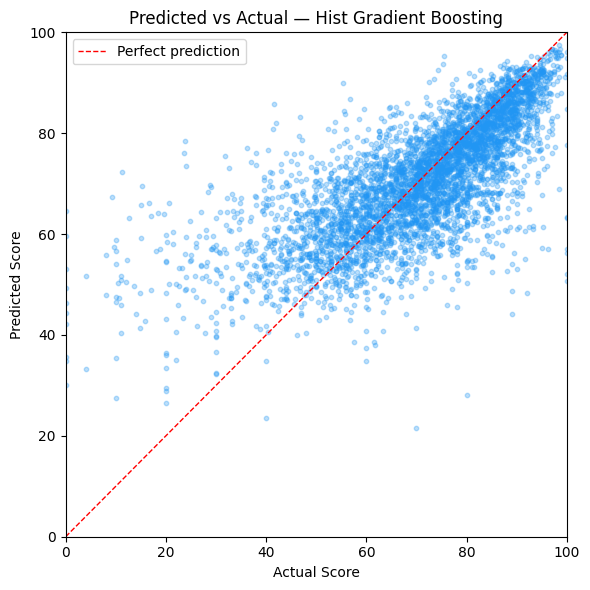

In [55]:
best_reg_name = reg_df_metrics.index[0]
y_pred_best = reg_results[best_reg_name]['_pred']

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_te, y_pred_best, alpha=0.3, s=10, color='#2196F3')
lims = [0, 100]
ax.plot(lims, lims, 'r--', linewidth=1, label='Perfect prediction')
ax.set_xlabel('Actual Score')
ax.set_ylabel('Predicted Score')
ax.set_title(f'Predicted vs Actual — {best_reg_name}')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.legend()
plt.tight_layout()
plt.show()

## 4.9 Feature Importance (Random Forest Regressor)

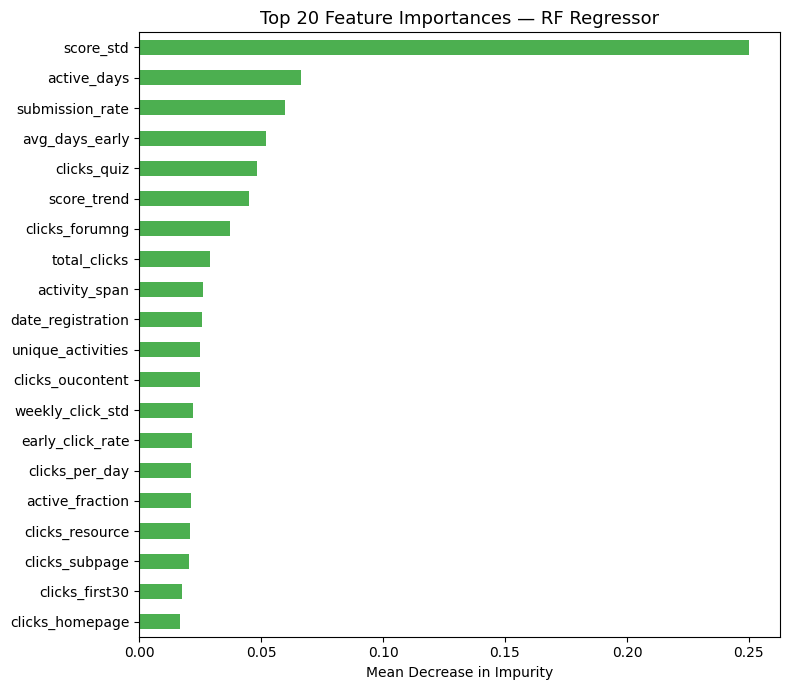

In [56]:
imp_reg = pd.Series(rf_reg.feature_importances_, index=reg_features)
top20_reg = imp_reg.nlargest(20).sort_values()

fig, ax = plt.subplots(figsize=(8, 7))
top20_reg.plot(kind='barh', ax=ax, color='#4CAF50')
ax.set_title('Top 20 Feature Importances — RF Regressor', fontsize=13)
ax.set_xlabel('Mean Decrease in Impurity')
plt.tight_layout()
plt.show()

## 4.10 Summary

In [57]:
print('=' * 50)
print('STEP 4 SUMMARY — Regression Results')
print('=' * 50)
print(reg_df_metrics.round(4).to_string())
print()
print(f'Best model : {reg_df_metrics.index[0]}')
print(f'Best RMSE  : {reg_df_metrics["RMSE"].min():.4f}')
print(f'Best R²    : {reg_df_metrics["R²"].max():.4f}')
print()
print('Next: Step 5 — Clustering (K-Means student segments)')

STEP 4 SUMMARY — Regression Results
                           RMSE      MAE      R²
Hist Gradient Boosting  11.4754   8.0943  0.5318
Random Forest           11.5496   8.0826  0.5258
Linear Regression       13.7089  10.1994  0.3319

Best model : Hist Gradient Boosting
Best RMSE  : 11.4754
Best R²    : 0.5318

Next: Step 5 — Clustering (K-Means student segments)


---
# Step 5: Clustering — Student Behavioural Segments

**Goal:** Use K-Means to discover natural student groups based purely on engagement and assessment behaviour — no outcome label used.

**Pipeline:** Feature selection → StandardScaler → Elbow + Silhouette → K-Means → Profile clusters → Visualise (PCA) → Validate against `final_result`

## 5.1 Select Clustering Features

Behavioural and assessment features only — demographics and the outcome label are excluded so clusters are driven by *how* students engage.

In [58]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler as SS
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

CLUSTER_FEATURES = [
    # VLE engagement
    'total_clicks', 'active_days', 'active_fraction', 'activity_span',
    'early_click_rate', 'click_trend', 'weekly_click_std',
    # Assessment behaviour
    'submission_rate', 'avg_days_early', 'score_trend', 'score_std',
]

# Use full master dataset; fill NaN with 0
clust_df = master[CLUSTER_FEATURES + ['final_result']].copy()
clust_df[CLUSTER_FEATURES] = clust_df[CLUSTER_FEATURES].fillna(0)

X_clust = clust_df[CLUSTER_FEATURES].values

print(f'Clustering matrix: {X_clust.shape}')
print('Features:', CLUSTER_FEATURES)

Clustering matrix: (32593, 11)
Features: ['total_clicks', 'active_days', 'active_fraction', 'activity_span', 'early_click_rate', 'click_trend', 'weekly_click_std', 'submission_rate', 'avg_days_early', 'score_trend', 'score_std']


## 5.2 Scale Features

K-Means is distance-based — z-score scaling is essential.

In [59]:
scaler_clust = SS()
X_scaled = scaler_clust.fit_transform(X_clust)
print('Scaling done. Mean ≈ 0, Std ≈ 1 per feature.')

Scaling done. Mean ≈ 0, Std ≈ 1 per feature.


## 5.3 Optimal k — Elbow Method & Silhouette Score

Run K-Means for k = 2 … 10 and inspect inertia (elbow) and silhouette score (higher = better-separated clusters).

k=2  inertia=236,166  silhouette=0.3435
k=3  inertia=191,304  silhouette=0.3098
k=4  inertia=161,693  silhouette=0.3504
k=5  inertia=145,334  silhouette=0.3573
k=6  inertia=131,775  silhouette=0.3787
k=7  inertia=119,883  silhouette=0.3404
k=8  inertia=109,443  silhouette=0.3534
k=9  inertia=101,839  silhouette=0.3548
k=10  inertia=95,436  silhouette=0.3560


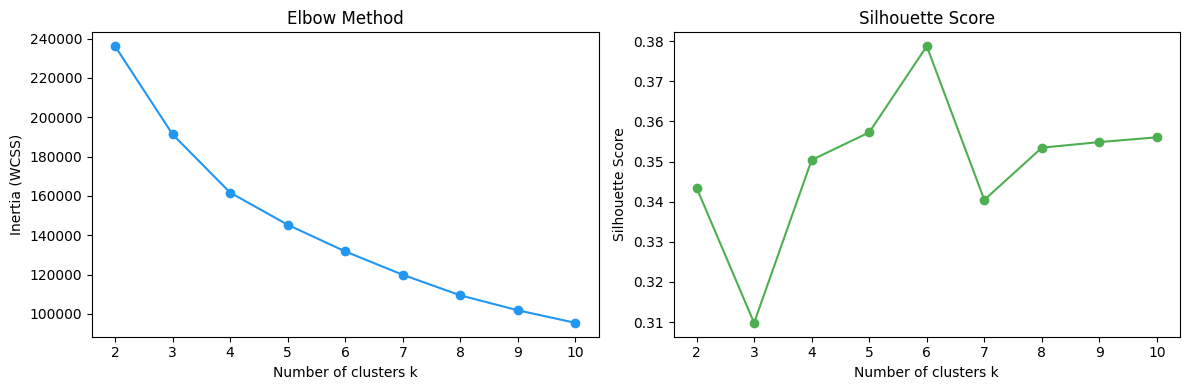


Best k by silhouette: 6


In [60]:
K_RANGE = range(2, 11)
inertias, sil_scores = [], []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels, sample_size=5000,
                                       random_state=RANDOM_STATE))
    print(f'k={k}  inertia={km.inertia_:,.0f}  silhouette={sil_scores[-1]:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(K_RANGE), inertias, 'o-', color='#2196F3')
axes[0].set_xlabel('Number of clusters k')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('Elbow Method')
axes[0].set_xticks(list(K_RANGE))

axes[1].plot(list(K_RANGE), sil_scores, 'o-', color='#4CAF50')
axes[1].set_xlabel('Number of clusters k')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score')
axes[1].set_xticks(list(K_RANGE))

plt.tight_layout()
plt.show()

best_k = list(K_RANGE)[sil_scores.index(max(sil_scores))]
print(f'\nBest k by silhouette: {best_k}')

## 5.4 Fit K-Means with Optimal k

Override `best_k` here if the elbow plot suggests a different value.

In [61]:
# Adjust if elbow plot suggests otherwise
K = best_k

km_final = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=20)
clust_df['cluster'] = km_final.fit_predict(X_scaled)

print(f'K-Means fitted with k={K}')
print()
print('Cluster sizes:')
print(clust_df['cluster'].value_counts().sort_index().to_string())

K-Means fitted with k=6

Cluster sizes:
cluster
0     6925
1    12871
2     2373
3     4905
4     3666
5     1853


## 5.5 Cluster Profiles

Mean of each feature per cluster — reveals what defines each group.

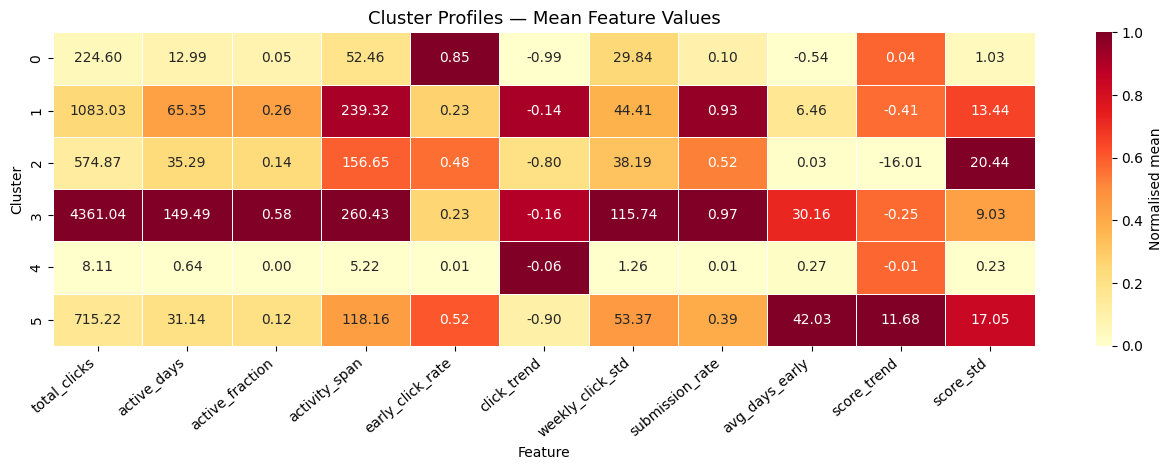

         total_clicks  active_days  active_fraction  activity_span  early_click_rate  click_trend  weekly_click_std  submission_rate  avg_days_early  score_trend  score_std
cluster                                                                                                                                                                     
0             224.603       12.988            0.051         52.461             0.850       -0.992            29.841            0.105          -0.542        0.040      1.031
1            1083.027       65.351            0.256        239.322             0.234       -0.137            44.406            0.928           6.457       -0.414     13.435
2             574.874       35.293            0.138        156.646             0.478       -0.801            38.190            0.517           0.034      -16.007     20.440
3            4361.037      149.487            0.582        260.430             0.226       -0.156           115.736            0.972   

In [62]:
profiles = clust_df.groupby('cluster')[CLUSTER_FEATURES].mean().round(3)

# Normalise to [0,1] per feature for heatmap readability
profiles_norm = (profiles - profiles.min()) / (profiles.max() - profiles.min() + 1e-9)

fig, ax = plt.subplots(figsize=(13, max(3, K * 0.8)))
sns.heatmap(profiles_norm, annot=profiles.values, fmt='.2f',
            cmap='YlOrRd', linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Normalised mean'})
ax.set_title('Cluster Profiles — Mean Feature Values', fontsize=13)
ax.set_xlabel('Feature')
ax.set_ylabel('Cluster')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()

print(profiles.to_string())

## 5.6 PCA 2D Visualisation

Project the scaled feature space to 2 principal components to visualise cluster separation.

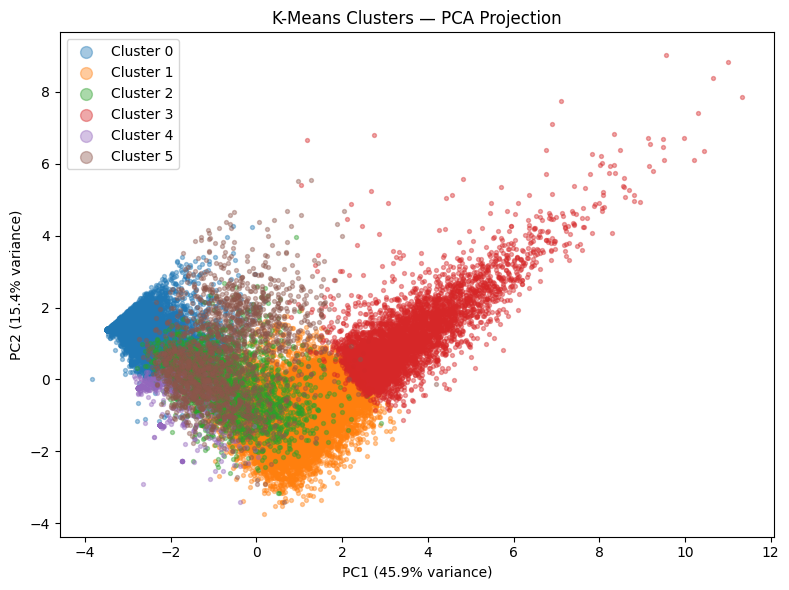

Variance explained by PC1+PC2: 61.3%


In [63]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
var_explained = pca.explained_variance_ratio_ * 100

fig, ax = plt.subplots(figsize=(8, 6))
colors = plt.cm.tab10.colors
for c in range(K):
    mask = clust_df['cluster'] == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               s=8, alpha=0.4, color=colors[c], label=f'Cluster {c}')
ax.set_xlabel(f'PC1 ({var_explained[0]:.1f}% variance)')
ax.set_ylabel(f'PC2 ({var_explained[1]:.1f}% variance)')
ax.set_title('K-Means Clusters — PCA Projection')
ax.legend(markerscale=3)
plt.tight_layout()
plt.show()

print(f'Variance explained by PC1+PC2: {sum(var_explained):.1f}%')

## 5.7 Cluster vs Final Result

Validate clusters against the known outcome — well-separated behavioural groups should map cleanly to Pass/Fail/Withdrawn/Distinction.

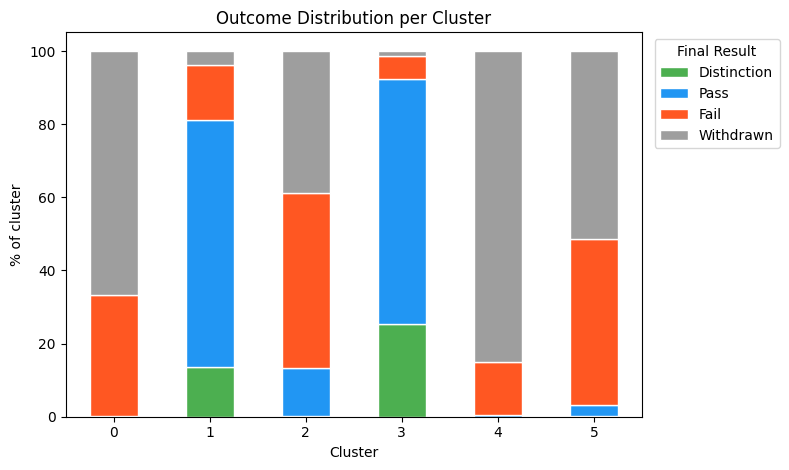

final_result  Distinction  Pass  Fail  Withdrawn
cluster                                         
0                     0.0   0.2  33.2       66.7
1                    13.7  67.5  15.1        3.7
2                     0.2  13.0  48.0       38.8
3                    25.3  67.0   6.2        1.4
4                     0.0   0.4  14.6       84.9
5                     0.3   2.9  45.3       51.5


In [64]:
ct = pd.crosstab(clust_df['cluster'], clust_df['final_result'],
                 normalize='index').round(3) * 100
ct = ct[['Distinction', 'Pass', 'Fail', 'Withdrawn']]

fig, ax = plt.subplots(figsize=(8, max(3, K * 0.8)))
ct.plot(kind='bar', stacked=True, ax=ax,
        color=[RESULT_PALETTE[c] for c in ct.columns],
        edgecolor='white')
ax.set_xlabel('Cluster')
ax.set_ylabel('% of cluster')
ax.set_title('Outcome Distribution per Cluster')
ax.legend(title='Final Result', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

print(ct.to_string())

## 5.8 Summary

In [65]:
print('=' * 55)
print('STEP 5 SUMMARY — K-Means Clustering')
print('=' * 55)
print(f'Optimal k         : {K}')
print(f'Silhouette score  : {max(sil_scores):.4f}')
print(f'PCA variance (2D) : {sum(var_explained):.1f}%')
print()
print('Cluster sizes:')
print(clust_df['cluster'].value_counts().sort_index().to_string())
print()
print('Next: Step 6 — Association Rule Mining (Apriori)')

STEP 5 SUMMARY — K-Means Clustering
Optimal k         : 6
Silhouette score  : 0.3787
PCA variance (2D) : 61.3%

Cluster sizes:
cluster
0     6925
1    12871
2     2373
3     4905
4     3666
5     1853

Next: Step 6 — Association Rule Mining (Apriori)


---
# Step 6: Association Rule Mining — Apriori

**Goal:** Discover co-occurring behavioural patterns and their link to student outcomes using the Apriori algorithm.

**Pipeline:** Install mlxtend → Discretise features → Binary encoding → Frequent itemsets → Association rules → Filter by lift → Visualise

## 6.0 Install mlxtend

In [66]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'mlxtend', '-q'])
print('mlxtend ready.')

mlxtend ready.


You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


## 6.1 Discretise Continuous Features

Apriori requires categorical items. Continuous features are binned into interpretable labels.

| Feature | Bins |
|---------|------|
| `total_clicks` | Low / Med / High (quantile thirds) |
| `active_fraction` | Low / Med / High (0–0.33 / 0.33–0.67 / 0.67–1) |
| `submission_rate` | Low / Med / High (0–0.5 / 0.5–0.8 / 0.8–1) |
| `click_trend` | Declining / Growing (≤ 0 / > 0) |
| `score_std` | Consistent / Erratic (≤ 15 / > 15) |
| `num_of_prev_attempts` | First attempt / Retake (0 / 1+) |
| `final_result` | as-is (Pass / Fail / Withdrawn / Distinction) |

In [67]:
arm_df = master[[
    'total_clicks', 'active_fraction', 'submission_rate',
    'click_trend', 'score_std', 'num_of_prev_attempts', 'final_result'
]].copy().fillna(0)

# total_clicks — quantile thirds
arm_df['clicks'] = pd.qcut(
    arm_df['total_clicks'], q=3, labels=['clicks=Low','clicks=Med','clicks=High']
)

# active_fraction
arm_df['activity'] = pd.cut(
    arm_df['active_fraction'],
    bins=[-0.01, 0.33, 0.67, 1.01],
    labels=['activity=Low','activity=Med','activity=High']
)

# submission_rate
arm_df['submission'] = pd.cut(
    arm_df['submission_rate'],
    bins=[-0.01, 0.5, 0.8, 1.01],
    labels=['submission=Low','submission=Med','submission=High']
)

# click_trend
arm_df['trend'] = arm_df['click_trend'].apply(
    lambda x: 'trend=Declining' if x <= 0 else 'trend=Growing'
)

# score_std
arm_df['consistency'] = arm_df['score_std'].apply(
    lambda x: 'score=Consistent' if x <= 15 else 'score=Erratic'
)

# prev_attempts
arm_df['attempts'] = arm_df['num_of_prev_attempts'].apply(
    lambda x: 'attempts=First' if x == 0 else 'attempts=Retake'
)

# outcome
arm_df['outcome'] = 'outcome=' + arm_df['final_result']

ITEM_COLS = ['clicks','activity','submission','trend','consistency','attempts','outcome']
arm_items = arm_df[ITEM_COLS].astype(str)

print('Sample transactions (first 5 rows):')
print(arm_items.head().to_string())

Sample transactions (first 5 rows):
        clicks      activity       submission            trend       consistency        attempts            outcome
0   clicks=Med  activity=Low  submission=High  trend=Declining  score=Consistent  attempts=First       outcome=Pass
1  clicks=High  activity=Low  submission=High  trend=Declining  score=Consistent  attempts=First       outcome=Pass
2   clicks=Med  activity=Low   submission=Low  trend=Declining  score=Consistent  attempts=First  outcome=Withdrawn
3  clicks=High  activity=Med  submission=High  trend=Declining  score=Consistent  attempts=First       outcome=Pass
4   clicks=Med  activity=Low  submission=High  trend=Declining     score=Erratic  attempts=First       outcome=Pass


## 6.2 Binary Transaction Matrix

In [68]:
from mlxtend.preprocessing import TransactionEncoder

transactions = arm_items.values.tolist()

te = TransactionEncoder()
te_array = te.fit_transform(transactions)
trans_df = pd.DataFrame(te_array, columns=te.columns_)

print(f'Transaction matrix: {trans_df.shape}')
print(f'Items: {list(te.columns_)}')

Transaction matrix: (32593, 19)
Items: ['activity=High', 'activity=Low', 'activity=Med', 'attempts=First', 'attempts=Retake', 'clicks=High', 'clicks=Low', 'clicks=Med', 'outcome=Distinction', 'outcome=Fail', 'outcome=Pass', 'outcome=Withdrawn', 'score=Consistent', 'score=Erratic', 'submission=High', 'submission=Low', 'submission=Med', 'trend=Declining', 'trend=Growing']


## 6.3 Frequent Itemsets

`min_support=0.05` means an itemset must appear in at least 5% of students.

In [69]:
from mlxtend.frequent_patterns import apriori

frequent_itemsets = apriori(
    trans_df,
    min_support=0.05,
    use_colnames=True,
    max_len=3
)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)

print(f'Total frequent itemsets: {len(frequent_itemsets)}')
print()
print('By itemset length:')
print(frequent_itemsets['length'].value_counts().sort_index().to_string())
print()
print('Top 10 by support:')
print(frequent_itemsets.sort_values('support', ascending=False)
      .head(10).to_string(index=False))

Total frequent itemsets: 288

By itemset length:
length
1     18
2     88
3    182

Top 10 by support:
 support                                            itemsets  length
0.871997                                    (attempts=First)       1
0.837726                                   (trend=Declining)       1
0.762096                                  (score=Consistent)       1
0.745344                                      (activity=Low)       1
0.729328                   (trend=Declining, attempts=First)       2
0.667106                  (attempts=First, score=Consistent)       2
0.654987                 (trend=Declining, score=Consistent)       2
0.639186                      (attempts=First, activity=Low)       2
0.636149                     (trend=Declining, activity=Low)       2
0.572546 (trend=Declining, attempts=First, score=Consistent)       3


## 6.4 Generate Association Rules

Filter to rules with `confidence ≥ 0.5` and `lift > 1.2` (lift > 1 means the consequent is more likely given the antecedent).

In [70]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(
    frequent_itemsets,
    metric='confidence',
    min_threshold=0.5
)
rules = rules[rules['lift'] > 1.2].sort_values('lift', ascending=False)

print(f'Rules after filtering (confidence≥0.5, lift>1.2): {len(rules)}')
print()
print('Top 15 rules by lift:')
display_cols = ['antecedents','consequents','support','confidence','lift']
print(rules[display_cols].head(15).to_string(index=False))

Rules after filtering (confidence≥0.5, lift>1.2): 281

Top 15 rules by lift:
                     antecedents                     consequents  support  confidence     lift
                  (activity=Med)     (outcome=Pass, clicks=High) 0.125518    0.596356 2.795487
     (outcome=Pass, clicks=High)                  (activity=Med) 0.125518    0.588379 2.795487
                  (activity=Med)  (clicks=High, submission=High) 0.170129    0.808309 2.794359
  (clicks=High, submission=High)                  (activity=Med) 0.170129    0.588142 2.794359
                  (activity=Med)  (trend=Declining, clicks=High) 0.142270    0.675948 2.755962
  (trend=Declining, clicks=High)                  (activity=Med) 0.142270    0.580060 2.755962
 (score=Consistent, clicks=High)                  (activity=Med) 0.152855    0.571527 2.715419
                  (activity=Med) (score=Consistent, clicks=High) 0.152855    0.726239 2.715419
(activity=Med, score=Consistent)                   (clicks=High) 0.1

## 6.5 Outcome-Focused Rules

Filter to rules whose **consequent is a student outcome** — these are the most actionable for intervention.

In [71]:
outcome_labels = {'outcome=Pass','outcome=Fail','outcome=Withdrawn','outcome=Distinction'}

def consequent_is_outcome(consequents):
    return bool(set(consequents) & outcome_labels)

outcome_rules = rules[rules['consequents'].apply(consequent_is_outcome)]\
    .sort_values('lift', ascending=False)

print(f'Outcome-predicting rules: {len(outcome_rules)}')
print()
print('Top 20 outcome rules:')
print(outcome_rules[display_cols].head(20).to_string(index=False))

Outcome-predicting rules: 58

Top 20 outcome rules:
                       antecedents                           consequents  support  confidence     lift
                    (activity=Med)           (outcome=Pass, clicks=High) 0.125518    0.596356 2.795487
      (submission=Low, clicks=Low)                   (outcome=Withdrawn) 0.209002    0.711882 2.284598
    (clicks=Low, score=Consistent)                   (outcome=Withdrawn) 0.201362    0.697153 2.237329
(submission=Low, score=Consistent)                   (outcome=Withdrawn) 0.261007    0.696439 2.235036
                  (submission=Low) (outcome=Withdrawn, score=Consistent) 0.261007    0.608338 2.225316
                      (clicks=Low) (outcome=Withdrawn, score=Consistent) 0.201362    0.603106 2.206177
                      (clicks=Low)   (submission=Low, outcome=Withdrawn) 0.209002    0.625988 2.188205
  (attempts=First, submission=Low)                   (outcome=Withdrawn) 0.244439    0.677293 2.173594
                  (su

## 6.6 Visualise — Support vs Confidence (coloured by Lift)

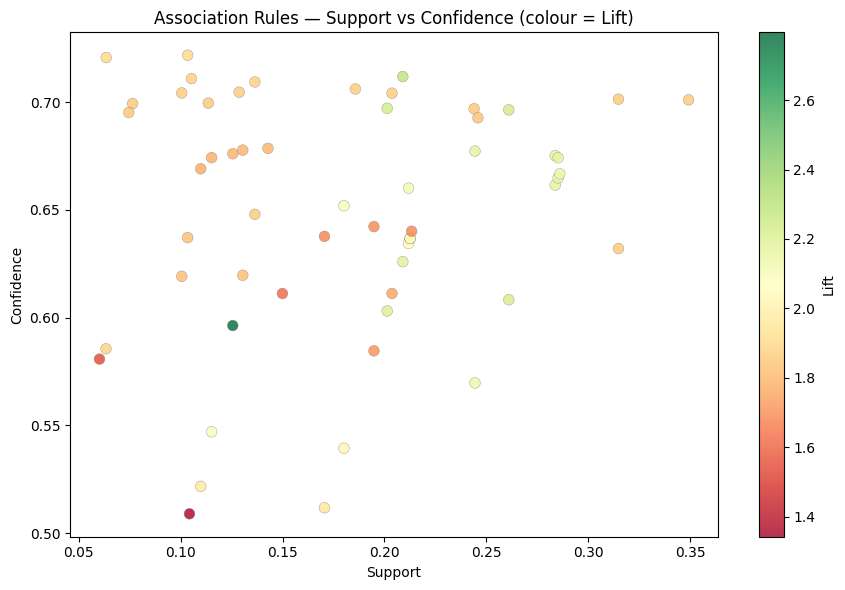

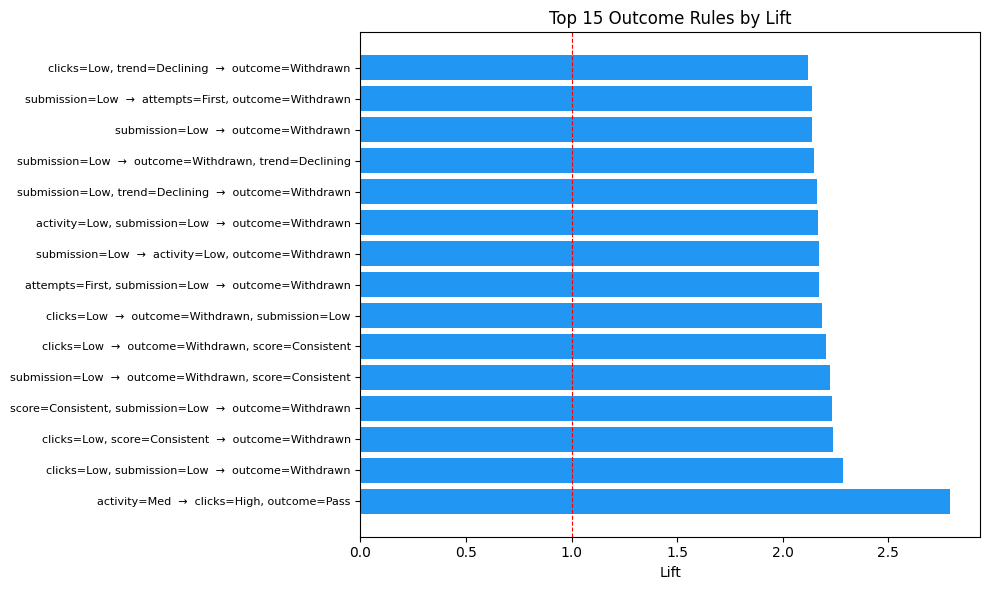

In [72]:
fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(
    outcome_rules['support'],
    outcome_rules['confidence'],
    c=outcome_rules['lift'],
    cmap='RdYlGn', s=60, alpha=0.8, edgecolors='grey', linewidths=0.3
)
plt.colorbar(sc, ax=ax, label='Lift')
ax.set_xlabel('Support')
ax.set_ylabel('Confidence')
ax.set_title('Association Rules — Support vs Confidence (colour = Lift)')
plt.tight_layout()
plt.show()

# Bar chart: top 15 outcome rules by lift
top15 = outcome_rules.head(15).copy()
top15['rule'] = (top15['antecedents'].apply(lambda x: ', '.join(sorted(x)))
                 + '  →  '
                 + top15['consequents'].apply(lambda x: ', '.join(sorted(x))))

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(top15)), top15['lift'].values, color='#2196F3')
ax.set_yticks(range(len(top15)))
ax.set_yticklabels(top15['rule'].values, fontsize=8)
ax.set_xlabel('Lift')
ax.set_title('Top 15 Outcome Rules by Lift')
ax.axvline(1.0, color='red', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

## 6.7 Summary

In [73]:
print('=' * 55)
print('STEP 6 SUMMARY — Association Rule Mining')
print('=' * 55)
print(f'Total frequent itemsets : {len(frequent_itemsets)}')
print(f'Total rules (filtered)  : {len(rules)}')
print(f'Outcome-predicting rules: {len(outcome_rules)}')
print()
print('Top 5 outcome rules by lift:')
print(outcome_rules[display_cols].head(5).to_string(index=False))
print()
print('Next: Step 7 — Insights & Recommendations')

STEP 6 SUMMARY — Association Rule Mining
Total frequent itemsets : 288
Total rules (filtered)  : 281
Outcome-predicting rules: 58

Top 5 outcome rules by lift:
                       antecedents                           consequents  support  confidence     lift
                    (activity=Med)           (outcome=Pass, clicks=High) 0.125518    0.596356 2.795487
      (submission=Low, clicks=Low)                   (outcome=Withdrawn) 0.209002    0.711882 2.284598
    (clicks=Low, score=Consistent)                   (outcome=Withdrawn) 0.201362    0.697153 2.237329
(submission=Low, score=Consistent)                   (outcome=Withdrawn) 0.261007    0.696439 2.235036
                  (submission=Low) (outcome=Withdrawn, score=Consistent) 0.261007    0.608338 2.225316

Next: Step 7 — Insights & Recommendations
